# HMM-GARCH Regime Strategy

This notebook builds a multi-factor Bitcoin accumulation signal combining a GARCH volatility model and a Hidden Markov Model (HMM) for regime detection.

### Table of Contents

1. **Data Loading & Feature Engineering** 
   Load on-chain metrics, compute log returns, rolling MVRV features, and transformed series.

2. **Time Series Diagnostics** 
   Stationarity tests (ADF, KPSS), ACF/PACF analysis to validate feature suitability for GARCH and HMM.

3. **STL Decomposition** 
   Trend/seasonal/residual decomposition of BTC price and MVRV to extract structural components.

4. **Volatility Clustering Diagnostics** 
   Ljung-Box and ARCH tests confirming autocorrelation and heteroskedasticity in returns.

5. **GARCH Volatility Model** 
   Fit a GARCH(1,1)-t model and extract conditional volatility used as an HMM input feature.

6. **Hidden Markov Model** 
   Fit a 3-state Gaussian HMM on [return, GARCH volatility, MVRV z-score, price vs active price] and assign regime labels.

7. **Allocation Signal Construction**  
   Combine regime probability, valuation adjustment, volatility percentile, and trend signal into a composite daily weight.

8. **Strategy Backtest & Evaluation** 
   Register `HMMGARCHV2Strategy`, run yearly exports (2018–2023), and compare sats per dollar vs uniform DCA baseline.

In [1]:
import duckdb
import sys
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pathlib import Path
import polars as pl

In [2]:
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config as src_config, data_utils, plots, strategy_utils

TRAIN_PATH = src_config.TRAIN_PATH
TEST_PATH = src_config.TEST_PATH

In [3]:
candidate_cols = [

    "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"


]

In [4]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [5]:
df = df.to_pandas()

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="all")

df.isna().mean().sort_values(ascending=False)

date              0.0
active_price      0.0
market_cap        0.0
mvrv              0.0
realized_price    0.0
supply_btc        0.0
price_usd         0.0
dtype: float64

In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

In [7]:
def plot_series(series, title=None):
    plt.figure(figsize=(12, 5))
    plt.plot(series)
    plt.title(title or series.name)
    plt.xlabel("Date")
    plt.ylabel(series.name)
    plt.show()

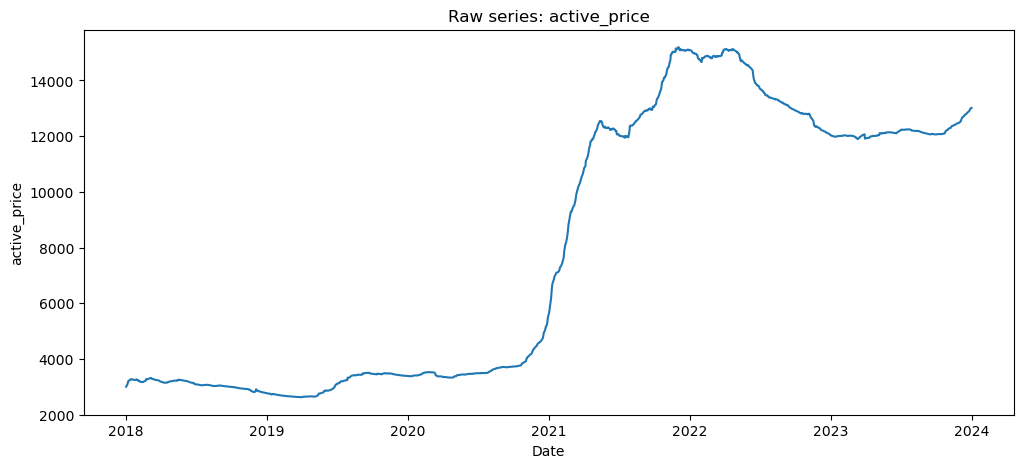

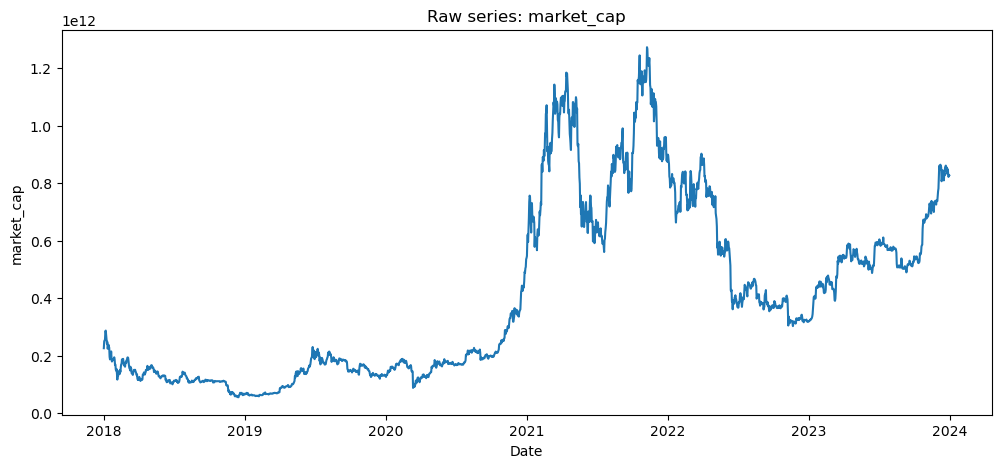

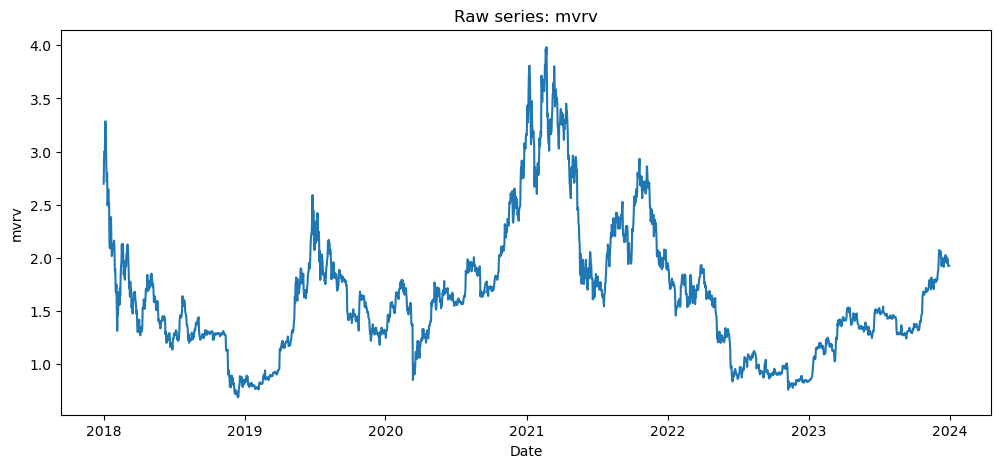

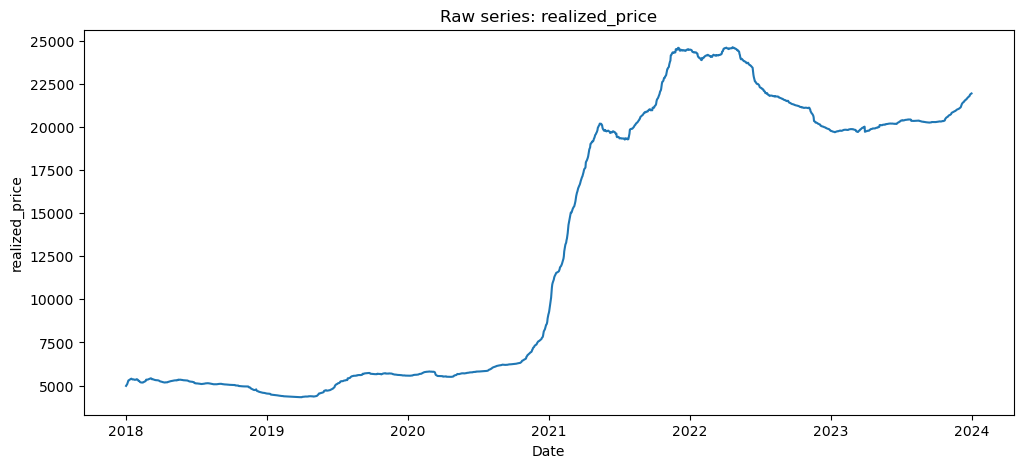

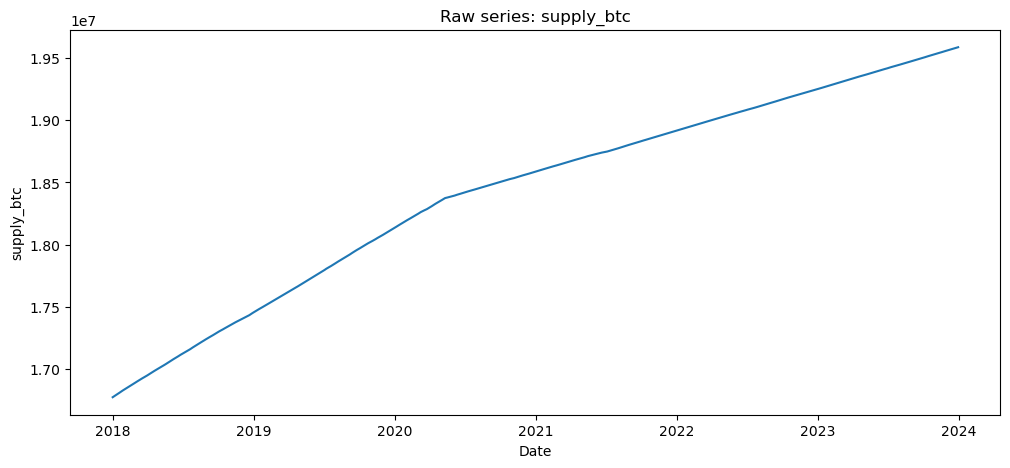

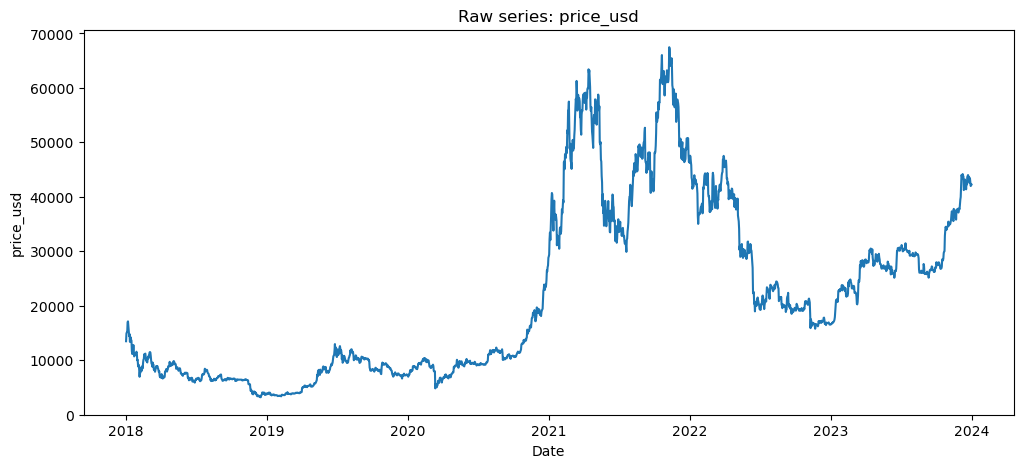

In [8]:
for col in df.columns:
    plot_series(df[col], f"Raw series: {col}")

In [9]:
ts = df.copy()

for col in df.columns:
    ts[f"log_{col}"] = np.log(ts[col].where(ts[col] > 0))
    ts[f"diff_{col}"] = ts[col].diff()
    ts[f"log_return_{col}"] = np.log(ts[col] / ts[col].shift(1))

In [10]:
ts["mvrv_deviation"] = ts["mvrv"] - ts["mvrv"].rolling(365).mean()
ts["mvrv_z_rolling"] = (
    (ts["mvrv"] - ts["mvrv"].rolling(365).mean())
    / ts["mvrv"].rolling(365).std()
)

In [11]:
def stationarity_tests(series, name=None):
    s = series.dropna()
    
    results = {"series": name or series.name}
    
    try:
        adf_result = adfuller(s, autolag="AIC") # ADF pvalue < 0.05 => reject null hypothesis of non-stationarity; conclusion: series is stationary
        results["adf_stat"] = adf_result[0]
        results["adf_pvalue"] = adf_result[1]
    except Exception:
        results["adf_stat"] = np.nan
        results["adf_pvalue"] = np.nan
    
    try:
        kpss_result = kpss(s, regression="c", nlags="auto") # KPSS pvalue > 0.05 => fail to reject null hypothesis of stationarity; conclusion: series is stationary
        results["kpss_stat"] = kpss_result[0]
        results["kpss_pvalue"] = kpss_result[1]
    except Exception:
        results["kpss_stat"] = np.nan
        results["kpss_pvalue"] = np.nan
    
    return results

In [12]:
test_cols = [
    "price_usd",
    "log_price_usd",
    "log_return_price_usd",
    "active_price",
    "log_active_price",
    "log_return_active_price",
    "mvrv",
    "mvrv_deviation",
    "mvrv_z_rolling",
]

stationarity_summary = pd.DataFrame([
    stationarity_tests(ts[col], col)
    for col in test_cols
    if col in ts.columns
])

stationarity_summary

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_39907/598866356.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression="c", nlags="auto") # KPSS pvalue > 0.05 => fail to reject null hypothesis of stationarity; conclusion: series is stationary
/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_39907/598866356.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression="c", nlags="auto") # KPSS pvalue > 0.05 => fail to reject null hypothesis of stationarity; conclusion: series is stationary
/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_39907/598866356.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up 

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,price_usd,-1.250029,0.651713,3.727000,0.010000
1,log_price_usd,-0.739511,0.836248,5.088784,0.010000
2,log_return_price_usd,-32.642921,0.000000,0.159539,0.100000
3,active_price,-0.791289,0.821668,6.221928,0.010000
4,log_active_price,-0.675748,0.852932,6.498280,0.010000
5,log_return_active_price,-4.603489,0.000127,0.513194,0.038695
6,mvrv,-2.859914,0.050212,0.751424,0.010000
7,mvrv_deviation,-2.373723,0.149291,0.692806,0.014199
8,mvrv_z_rolling,-2.281830,0.177895,0.502037,0.041208


In [13]:
stationarity_summary[stationarity_summary["adf_pvalue"] < 0.05]

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
2,log_return_price_usd,-32.642921,0.000000,0.159539,0.100000
5,log_return_active_price,-4.603489,0.000127,0.513194,0.038695


In [14]:
stationarity_summary[stationarity_summary["kpss_pvalue"] > 0.05]

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
2,log_return_price_usd,-32.642921,0.0,0.159539,0.1


### Only log return of the price is stationary across both tests

In [15]:
def plot_acf_pacf(series, lags=60):
    s = series.dropna()
    
    plot_acf(s, lags=lags)
    plt.title(f"ACF: {series.name}")
    plt.show()
    
    plot_pacf(s, lags=lags, method="ywm")
    plt.title(f"PACF: {series.name}")
    plt.show()

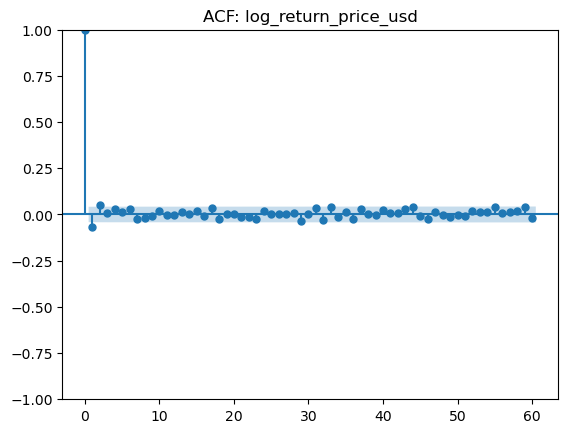

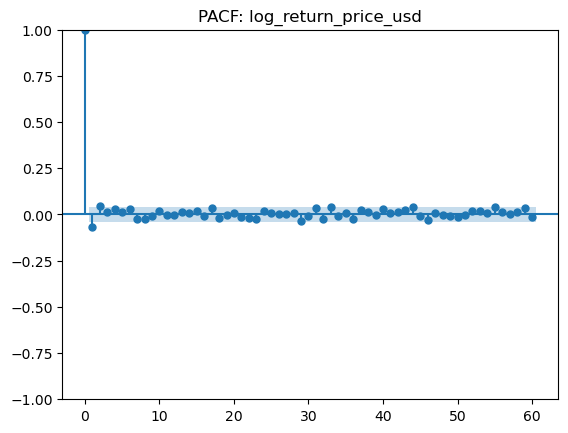

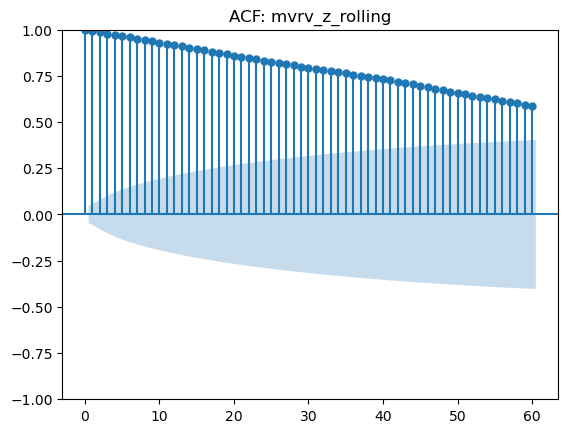

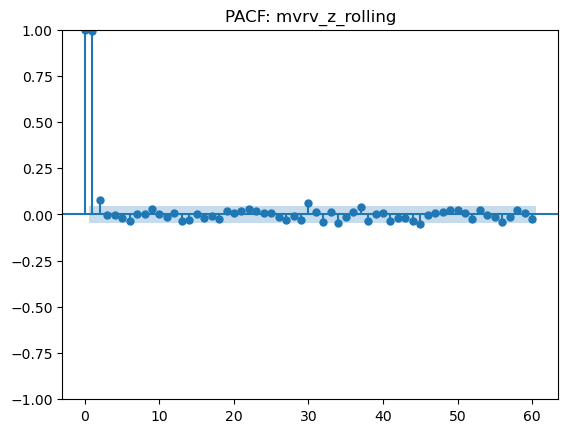

In [16]:
plot_acf_pacf(ts["log_return_price_usd"], lags=60)
plot_acf_pacf(ts["mvrv_z_rolling"], lags=60)

In [17]:
# observed = trend + seasonal + residual
# STL decomposition can help us understand the underlying components of a time series, such as the trend, seasonality, and residuals. 
# This can be useful for identifying patterns and making forecasts.
def stl_decompose(series, period=30, robust=True):
    s = series.dropna()
    model = STL(s, period=period, robust=robust)
    result = model.fit()
    return result

## Check the residual plot over time

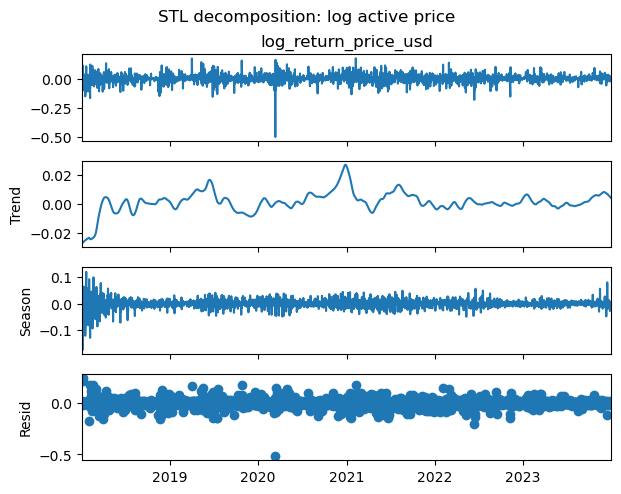

In [18]:
active_stl = stl_decompose(ts["log_return_price_usd"], period=30)

active_stl.plot()
plt.suptitle("STL decomposition: log active price", y=1.02)
plt.show()

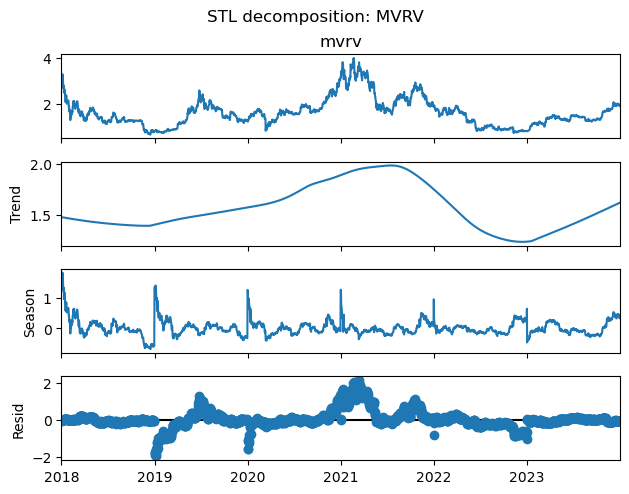

In [19]:
mvrv_stl = stl_decompose(ts["mvrv"], period=365)

mvrv_stl.plot()
plt.suptitle("STL decomposition: MVRV", y=1.02)
plt.show()

In [20]:
# Create detrended / deseasonalized series using the STL decomposition results
# The trend component captures the long-term progression of the series, while the seasonal component captures the repeating patterns. 
# The residual component captures the remaining variability after removing the trend and seasonality. 
# By creating detrended and deseasonalized series, we can analyze the underlying patterns and make forecasts without the influence of trend and seasonality.
def add_stl_features(df, col, period=30):
    result = stl_decompose(df[col], period=period)
    
    out = df.copy()
    out[f"{col}_trend"] = result.trend
    out[f"{col}_seasonal"] = result.seasonal
    out[f"{col}_resid"] = result.resid
    out[f"{col}_detrended"] = df[col] - result.trend
    out[f"{col}_deseasonalized"] = df[col] - result.seasonal
    
    return out

In [21]:
ts = add_stl_features(ts, "log_active_price", period=30)
ts = add_stl_features(ts, "mvrv", period=365)

In [22]:
ts.head()

,active_price,market_cap,mvrv,realized_price,supply_btc,price_usd,log_active_price,diff_active_price,log_return_active_price,log_market_cap,...,log_active_price_trend,log_active_price_seasonal,log_active_price_resid,log_active_price_detrended,log_active_price_deseasonalized,mvrv_trend,mvrv_seasonal,mvrv_resid,mvrv_detrended,mvrv_deseasonalized
date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,3006.298120,2.259147e+11,2.697882,4982.419500,1.677629e+07,13466.31,8.008465,NaN,NaN,26.143423,...,8.076849,-0.018303,-0.050081,-0.068384,8.026768,1.482824,1.221073,-0.006015,1.215058,1.476809
2018-01-02,3029.016372,2.497990e+11,2.944071,5017.076367,1.677842e+07,14888.11,8.015993,22.718251,0.007528,26.243922,...,8.077204,-0.007009,-0.054203,-0.061211,8.023002,1.482387,1.492714,-0.031029,1.461685,1.451358
2018-01-03,3047.247163,2.533526e+11,3.001065,5046.828811,1.678039e+07,15098.14,8.021994,18.230791,0.006001,26.258048,...,8.077560,-0.018553,-0.037013,-0.055566,8.040547,1.481951,1.525150,-0.006036,1.519114,1.475915
2018-01-04,3072.132815,2.541706e+11,2.985702,5087.183014,1.678249e+07,15144.99,8.030127,24.885652,0.008133,26.261271,...,8.077916,-0.021151,-0.026638,-0.047788,8.051278,1.481516,1.510233,-0.006047,1.504186,1.475469
2018-01-05,3119.591494,2.846614e+11,3.285019,5161.573986,1.678427e+07,16960.01,8.045457,47.458679,0.015330,26.374566,...,8.078272,-0.015026,-0.017788,-0.032814,8.060484,1.481081,1.809995,-0.006057,1.803938,1.475024


The residual/detrended component may be more useful than the raw metric. It tells us when the metric is unusually high or low relative to its own structure

In [23]:
def diagnostic_tests(series, lags=20):
    s = series.dropna()
    
    lb = acorr_ljungbox(s, lags=[lags], return_df=True)
    arch = het_arch(s)
    
    return {
        "series": series.name,
        "ljung_box_pvalue": lb["lb_pvalue"].iloc[0],
        "arch_stat": arch[0],
        "arch_pvalue": arch[1],
    }

Ljung-Box p-value < 0.05 → autocorrelation exists
ARCH p-value < 0.05      → volatility clustering exists

In [24]:
diagnostic_summary = pd.DataFrame([
    diagnostic_tests(ts[col])
    for col in [
        "log_return_price_usd",
        "mvrv_z_rolling",
        "log_active_price_resid",
        "mvrv_resid",
    ]
    if col in ts.columns
])

diagnostic_summary

,series,ljung_box_pvalue,arch_stat,arch_pvalue
0,log_return_price_usd,0.078302,40.372106,0.000015
1,mvrv_z_rolling,0.000000,1693.648316,0.000000
2,log_active_price_resid,0.000000,2039.572602,0.000000
3,mvrv_resid,0.000000,1997.447856,0.000000


```
Market Data
    ↓
Time Series Diagnostics
    ↓
GARCH Volatility Estimation
    ↓
Feature Construction
    ↓
Hidden Markov Regime Detection
    ↓
Regime-Aware DCA Signal
    ↓
Stacksats Backtesting
```

In [25]:
from arch import arch_model

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

In [26]:
model_df = ts.copy()

model_df["btc_log_return"] = np.log(
    model_df["price_usd"] / model_df["price_usd"].shift(1)
)

model_df["btc_return_pct"] = model_df["btc_log_return"] * 100

model_df = model_df.replace([np.inf, -np.inf], np.nan)

GARCH is used to analyze and forecast volatility in time-series data, particularly in financial markets. It helps investors and risk managers estimate how much the price of an asset is likely to fluctuate

GARCH works better when returns are expressed in percentage terms rather than tiny decimals.

In [27]:
returns = model_df["btc_return_pct"].dropna()

garch = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch.fit(disp="off")

print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               btc_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5576.05
Distribution:      Standardized Student's t   AIC:                           11162.1
Method:                  Maximum Likelihood   BIC:                           11190.6
                                              No. Observations:                 2190
Date:                      Wed, Jun 17 2026   Df Residuals:                     2189
Time:                              15:59:31   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

mean="Constant" → returns have weak predictability, so simple mean is enough
vol="GARCH"     → ARCH effects exist, so variance is time-varying
p=1, q=1        → standard baseline volatility model
dist="t"        → crypto returns are fat-tailed, so Student-t is better than Gaussian

In [28]:
model_df.loc[returns.index, "garch_volatility"] = garch_result.conditional_volatility

In [29]:
garch_result.conditional_volatility

date
2018-01-02    6.649021
2018-01-03    6.944014
2018-01-04    6.711726
2018-01-05    6.479017
2018-01-06    6.933045
                ...   
2023-12-27    2.529292
2023-12-28    2.511390
2023-12-29    2.491696
2023-12-30    2.457834
2023-12-31    2.396057
Name: cond_vol, Length: 2190, dtype: float64

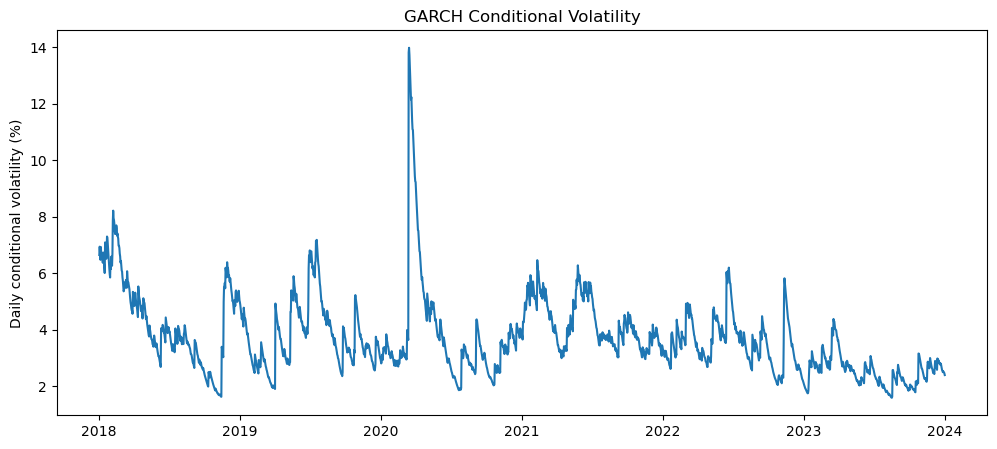

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(model_df["garch_volatility"])
plt.title("GARCH Conditional Volatility")
plt.ylabel("Daily conditional volatility (%)")
plt.show()

* Spikes = high-risk regimes
* Low values = calmer accumulation periods

`HMM implementation`

return          → short-term direction
volatility      → risk regime
mvrv_z          → valuation regime
price_vs_active → recent participant profit/loss state

In [31]:
model_df.columns

Index(['active_price', 'market_cap', 'mvrv', 'realized_price', 'supply_btc',
       'price_usd', 'log_active_price', 'diff_active_price',
       'log_return_active_price', 'log_market_cap', 'diff_market_cap',
       'log_return_market_cap', 'log_mvrv', 'diff_mvrv', 'log_return_mvrv',
       'log_realized_price', 'diff_realized_price',
       'log_return_realized_price', 'log_supply_btc', 'diff_supply_btc',
       'log_return_supply_btc', 'log_price_usd', 'diff_price_usd',
       'log_return_price_usd', 'mvrv_deviation', 'mvrv_z_rolling',
       'log_active_price_trend', 'log_active_price_seasonal',
       'log_active_price_resid', 'log_active_price_detrended',
       'log_active_price_deseasonalized', 'mvrv_trend', 'mvrv_seasonal',
       'mvrv_resid', 'mvrv_detrended', 'mvrv_deseasonalized', 'btc_log_return',
       'btc_return_pct', 'garch_volatility'],
      dtype='str')

In [32]:
hmm_features = pd.DataFrame(index=model_df.index)

hmm_features["return"] = model_df["btc_log_return"]
hmm_features["volatility"] = model_df["garch_volatility"]
hmm_features["mvrv_z"] = model_df["mvrv_z_rolling"]
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()

In [33]:
scaler = StandardScaler()

X = scaler.fit_transform(hmm_features)

State 1 → accumulation / undervalued
State 2 → neutral / transition
State 3 → overheated / high-risk

In [34]:
from stacksats.runner import StrategyRunner
from stacksats import BacktestConfig, ComparisonConfig
from stacksats.strategies import UniformStrategy
from stacksats import BaseStrategy
from stacksats import DayState, ExportConfig

uniform_strategy = UniformStrategy()

config = BacktestConfig(
    start_date="2019-01-01",
    end_date="2024-01-01"
)

runner = StrategyRunner()


In [35]:
# returns -> Short term price movement, more stable than raw price
# volatility -> measure of risk, can indicate market uncertainty
# mvrv_z -> valuation metric, can indicate if market is overvalued or undervalued
# price_vs_active -> market demand vs supply, can indicate buying pressure/holder profitability

In [36]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

regime_probs = hmm.predict_proba(X)

In [37]:
hmm_features["regime"] = hmm.predict(X)

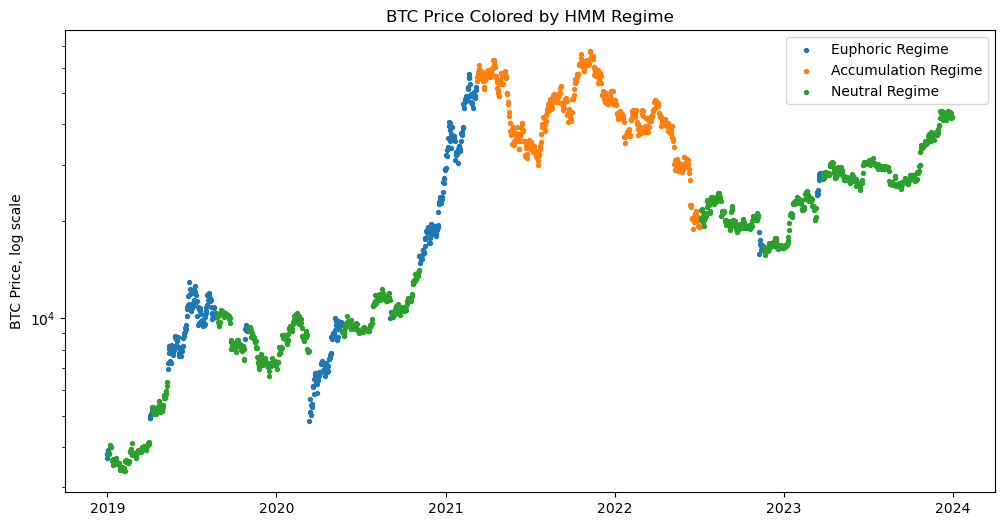

In [38]:
plot_df = model_df.join(hmm_features["regime"], how="left")

plt.figure(figsize=(12, 6))

regime_map = {
    '0':'Euphoric',
    '1': 'Accumulation',
    '2': 'Neutral'
}

for regime in sorted(plot_df["regime"].dropna().unique()):
    subset = plot_df[plot_df["regime"] == regime]
    
    plt.scatter(
        subset.index,
        subset["price_usd"],
        s=8,
        label=f"{regime_map[str(int(regime))]} Regime"
    )

plt.yscale("log")
plt.title("BTC Price Colored by HMM Regime")
plt.ylabel("BTC Price, log scale")
plt.legend()
plt.show()

In [39]:
# This gives us the probability of being in each regime for each day, 
# which we can use to create a more nuanced allocation strategy that weights the regimes by their probabilities instead of making hard assignments.
# Markets don't just switch from "overheated" to "accumulation" overnight - there are often transition periods where the probabilities are more mixed.

In [40]:
for i in range(hmm.n_components):
    hmm_features[f"regime_prob_{i}"] = regime_probs[:, i]

In [41]:
prob_cols = [f"regime_prob_{i}" for i in range(hmm.n_components)]

plot_df = model_df.join(
    hmm_features[["regime"] + prob_cols],
    how="left"
)

plot_df = plot_df.rename(columns={"regime": "hmm_regime"})

In [42]:
regime_summary = (
    hmm_features
    .groupby("regime")
    .mean()
)

regime_summary

,return,volatility,mvrv_z,price_vs_active,regime_prob_0,regime_prob_1,regime_prob_2
regime,,,,,,,
0,0.006480,5.216008,1.379440,2.420407,0.979914,0.002754,0.017332
1,-0.001964,3.954175,-0.617299,2.312177,0.000783,0.997434,0.001783
2,0.001105,2.880455,0.251039,1.248468,0.005578,0.000239,0.994183


In [43]:
# Based on the regime summary, we can assign labels to the regimes.
# We assign based on mvrv_z_rolling because it is a valuation metric, which is often the most important factor for long-term accumulation strategies.
# Using just return or volatility could lead to assigning the regimes to mostly
# calm or volatile periods but might miss out on valuation context which mvrv_z_rolling provides, that might not be ideal for a long-term accumulation strategy.
# This way the model can distinguish between periods that are undervalued but volatile (good buying opportunities) vs 
# overvalued and volatile (bad buying opportunities), which is crucial for a strategy focused on accumulating more BTC over time.
euphoric_regime = 0
accumulation_regime = 1
neutral_regime = 2

In [44]:
regime_multiplier = {
    0.0: 0.50,  # high risk
    1.0: 1.75,  # undervalued accumulation
    2.0: 1.00,  # neutral
}

# The next cell assigns a regime weight based on a combination of the regime we are in and its multiplier
# So if we are in an undervalued regime (1), the multiplier is 1.75, which means we want to buy 75% more than our baseline allocation.
# If we are in an overheated regime (0), the multiplier is 0.5, which means we want to buy 50% less than our baseline allocation.
# If we are in a neutral regime (2), the multiplier is 1.0, which means we want to buy the same as our baseline allocation.

In [45]:
plot_df["prob_regime_weight"] = (
    plot_df[f"regime_prob_{euphoric_regime}"] * regime_multiplier[euphoric_regime]
    + plot_df[f"regime_prob_{accumulation_regime}"] * regime_multiplier[accumulation_regime]
    + plot_df[f"regime_prob_{neutral_regime}"] * regime_multiplier[neutral_regime]
)

In [46]:
#mvrv_z = +1.0 → 0, not cheap
#mvrv_z = -1.0 → 1, moderately cheap
#mvrv_z = -2.0 → 2, very cheap
#0 = not undervalued
#1 = strongly undervalued
plot_df["valuation_signal"] = (
    -plot_df["mvrv_z_rolling"]
).clip(lower=0)

In [47]:
# Based on how undervalued the market is, we can create a valuation signal where 0 means not undervalued and 2 means very undervalued.
# We clip it to prevent a big boost when negative (very overvalued). We only want to boost buying when the market is undervalued, not when it's overvalued.
# We will then adjust accumulation intensity based on valuation severity

In [48]:
# valuation signal has range [0, 2], we can create an adjustment that gives a multiplier of 1.0x when normal (we buy at DCA levels)
# 1.5x when moderately undervalued, and 2.0x when very undervalued

In [49]:
plot_df["valuation_adjustment"] = (
    1 + 0.50 * plot_df["valuation_signal"]
)

In [50]:
# We get the rolling volatility from the GARCH model, which gives us a measure of how volatile the market is on each day.
# We can then create a volatility adjustment that reduces our buying when volatility is high and the market is overvalued, 
# since high volatility can indicate increased risk and uncertainty in the market.
# and increases our buying when volatility is high but the market is undervalued, since that could indicate a good buying opportunity 

In [51]:
plot_df["volatility_percentile"] = (
    plot_df["garch_volatility"]
    .rolling(365)
    .rank(pct=True)
)

In [52]:
# Cheap + high volatility     → panic opportunity → buy more
# Expensive + high volatility → risk/euphoria     → buy slightly less

plot_df["volatility_adjustment"] = 1.0

cheap_market = plot_df["valuation_signal"] > 0.5

plot_df.loc[cheap_market, "volatility_adjustment"] = (
    1 + 0.40 * plot_df.loc[cheap_market, "volatility_percentile"]
)

plot_df.loc[~cheap_market, "volatility_adjustment"] = (
    1 - 0.20 * plot_df.loc[~cheap_market, "volatility_percentile"]
)

In [53]:
# This is a long term trend filter. It gives an indication of broader market structure (whether the market is in a long term uptrend or downtrend) 
# which can help avoid buying too much in a prolonged bear market.

In [54]:
plot_df["price_200d_ma"] = (
    plot_df["price_usd"]
    .rolling(200)
    .mean()
)

plot_df["trend_signal"] = (
    plot_df["price_usd"] > plot_df["price_200d_ma"]
).astype(float)

plot_df["trend_adjustment"] = np.where(
    plot_df["trend_signal"] == 1,
    1.05,
    0.95
)


# Positive trend → slightly more confidence
# Negative trend → slightly more caution

In [55]:
# final weight =
#     regime belief
#   × valuation opportunity
#   × volatility context
#   × trend context


# HMM regime probabilities → what market state are we probably in?
# MVRV valuation           → is BTC cheap or expensive?
# GARCH volatility         → is stress high or low?
# Trend filter             → is the broader price structure supportive (up or down)?

In [56]:
plot_df["hmm_garch_v2_allocation_weight"] = (
    plot_df["prob_regime_weight"]
    * plot_df["valuation_adjustment"]
    * plot_df["volatility_adjustment"]
    * plot_df["trend_adjustment"]
).clip(0.50, 2.50)

In [57]:
# Smooth the allocation weight with a 7-day rolling average to avoid too much day-to-day noise in the allocation.

In [58]:
plot_df["hmm_garch_v2_allocation_weight"] = (
    plot_df["hmm_garch_v2_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(plot_df["hmm_garch_v2_allocation_weight"])
)

In [59]:
plot_df["hmm_garch_v2_allocation_weight"] = (

    plot_df["hmm_garch_v2_allocation_weight"]

    .shift(1)

    .fillna(1.0)

)

In [60]:
signal_cols = [
    "hmm_garch_v2_allocation_weight",
    "prob_regime_weight",
    "valuation_adjustment",
    "volatility_adjustment",
    "trend_adjustment",
    "hmm_regime",
]

signals_pd = (
    plot_df
    .reset_index()
    [["date"] + signal_cols]
)

btc_df = (
    df.reset_index()
    .merge(signals_pd, on="date", how="left")
)

btc_df["hmm_garch_v2_allocation_weight"] = (
    btc_df["hmm_garch_v2_allocation_weight"]
    .fillna(1.0)
)

In [61]:
import polars as pl

btc_df_pl = pl.from_pandas(btc_df).with_columns(
    pl.col("date").cast(pl.Date)
)

In [62]:
btc_df_pl.select([
    pl.col("hmm_garch_v2_allocation_weight").mean().alias("mean_signal"),
    pl.col("hmm_garch_v2_allocation_weight").min().alias("min_signal"),
    pl.col("hmm_garch_v2_allocation_weight").max().alias("max_signal"),
    pl.col("hmm_garch_v2_allocation_weight").std().alias("std_signal"),
])

mean_signal,min_signal,max_signal,std_signal
f64,f64,f64,f64
1.292047,0.5,2.5,0.617903


In [63]:
# class HMMGARCHV2Strategy(BaseStrategy):
#     strategy_id = "hmm-garch-v2"
#     version = "1.0.0"

#     def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
#         self.min_weight = min_weight
#         self.max_weight = max_weight

#         self.signal_df = (
#             signal_df
#             .select(["date", "hmm_garch_v2_allocation_weight"])
#             .with_columns(pl.col("date").cast(pl.Date))
#         )

#     def propose_weight(self, state):
#         current_date = (
#             state.features
#             .select("date")
#             .tail(1)
#             .item()
#         )

#         signal_row = self.signal_df.filter(
#             pl.col("date") == current_date
#         )

#         if signal_row.is_empty():
#             signal = 1.0
#         else:
#             signal = (
#                 signal_row
#                 .select("hmm_garch_v2_allocation_weight")
#                 .item()
#             )

#         if signal is None:
#             signal = 1.0

#         signal = float(signal)
#         signal = max(self.min_weight, min(signal, self.max_weight))

#         return state.uniform_weight * signal

In [64]:
class HMMGARCHV2Strategy(BaseStrategy):
    strategy_id = "hmm-garch-v2"
    version = "1.0.0"

    def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
        self.min_weight = min_weight
        self.max_weight = max_weight

        self.signal_df = (
            signal_df
            .select(["date", "hmm_garch_v2_allocation_weight"])
            .with_columns(pl.col("date").cast(pl.Date))
        )

    def params(self):
        return {
            "min_weight": self.min_weight,
            "max_weight": self.max_weight,
            "signal_column": "hmm_garch_v2_allocation_weight",
        }

    def propose_weight(self, state):
        current_date = (
            state.features
            .select("date")
            .tail(1)
            .item()
        )

        signal_row = self.signal_df.filter(
            pl.col("date") == current_date
        )

        if signal_row.is_empty():
            signal = 1.0
        else:
            signal = (
                signal_row
                .select("hmm_garch_v2_allocation_weight")
                .item()
            )

        if signal is None:
            signal = 1.0

        signal = float(signal)
        signal = max(self.min_weight, min(signal, self.max_weight))

        return state.uniform_weight * signal

In [65]:
hmm2 = HMMGARCHV2Strategy(signal_df=btc_df_pl)

In [66]:
start_date = btc_df_pl.select(pl.col("date").min()).item()
end_date = btc_df_pl.select(pl.col("date").max()).item()

print(f"Backtesting from {start_date} to {end_date}")

Backtesting from 2018-01-01 to 2023-12-31


In [67]:
hmm2_bt = runner.backtest(
    hmm2,
    config=BacktestConfig(
        start_date=str(start_date),
        end_date=str(end_date),
    ),
    btc_df=btc_df_pl,
)
hmm2_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,14736.064632,34.766505,34.766505,2.2027e-13
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,14787.64918,34.968165,34.968165,1.9895e-13
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,14839.550357,35.171063,35.171063,2.0606e-13
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,14893.711999,35.383081,35.382798,-0.000282
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,14947.374082,35.592341,35.592581,0.00024
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,3696.380322,36.43953,37.778119,1.338589
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,3681.753433,36.172452,37.392363,1.219911
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,3667.419917,35.910124,37.014345,1.10422


In [68]:
hmm2_bt.summary()

'Score: 45.95% | Win Rate: 52.55% | Exp-Decay Percentile: 39.36% | Uniform Exp-Decay: 37.29% | Exp-Decay Multiple: 1.055x | Windows: 1827'

In [69]:
strategies_train = {
    "dynamic": hmm2,
    "baseline": UniformStrategy(),
}

train_years  = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR)   # 2018–2023
merged_train = strategy_utils.run_year_by_year(strategies_train, btc_df_pl, train_years, runner)

perf_vf   = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")

print(f"[Train] HMM-GARCH SPD : {perf_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_vf['sats_per_dollar_baseline']:.2f}")
print(f"HMM-GARCH {abs(perf_vf['pct_diff_vs_baseline']):.2f}% {perf_vf['performance_label']} than Uniform")

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
[Train] HMM-GARCH SPD : 8663.86
[Train] Baseline SPD    : 8418.79
HMM-GARCH 2.91% better than Uniform


## Adding Test data

In [70]:
df_test = (
    pl.scan_parquet(TEST_PATH)
    .filter(pl.col("day_utc") >= pl.date(2024, 1, 1)) #Test data should anyways start from Jan 1, 2024
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [71]:
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)
df = df.to_pandas()
test_df = df_test.to_pandas()


combined = pd.concat([

    df.tail(365),

    test_df

])

combined["mvrv_z_rolling"] = (

    combined["mvrv"]

    - combined["mvrv"].rolling(365).mean()

) / combined["mvrv"].rolling(365).std()

In [72]:
test_df["mvrv_z_rolling"] = combined.loc[

    test_df.index,

    "mvrv_z_rolling"

]

def make_base_features(df):
    out = df.copy()

    out["btc_log_return"] = np.log(
        out["price_usd"] / out["price_usd"].shift(1)
    )

    out["btc_return_pct"] = out["btc_log_return"] * 100

    out["price_vs_active"] = (
        out["price_usd"] / out["active_price"] - 1
    )

    out["price_200d_ma"] = (
        out["price_usd"]
        .rolling(200)
        .mean()
    )

    out["trend_state"] = np.where(
        out["price_usd"] > out["price_200d_ma"],
        "uptrend",
        "downtrend"
    )

    return out


test_raw = test_df.copy()
test_raw["date"] = pd.to_datetime(test_raw["date"])
test_raw = test_raw.sort_values("date").set_index("date")
test_model_df = make_base_features(test_raw)

In [73]:
test_model_df["garch_volatility"] = (
    test_model_df["btc_return_pct"]
    .rolling(30)
    .std()
)


hmm_feature_cols = [
    "btc_log_return",
    "garch_volatility",
    "mvrv_z_rolling",
    "price_vs_active",
]

test_hmm_features = pd.DataFrame(index=test_model_df.index)
test_hmm_features["return"] = test_model_df["btc_log_return"]
test_hmm_features["volatility"] = test_model_df["garch_volatility"]
test_hmm_features["mvrv_z"] = test_model_df["mvrv_z_rolling"]
test_hmm_features["price_vs_active"] = (
    test_model_df["price_usd"] / test_model_df["active_price"] - 1
)


test_hmm_features = test_hmm_features.replace(

    [np.inf, -np.inf], np.nan

).dropna()

In [74]:
test_hmm_features = test_hmm_features[[
    "return",
    "volatility",
    "mvrv_z",
    "price_vs_active",
]]
X_test = scaler.transform(test_hmm_features)

test_regimes = hmm.predict(X_test)
test_regime_probs = hmm.predict_proba(X_test)

test_hmm_features["hmm_regime"] = test_regimes

for i in range(hmm.n_components):
    test_hmm_features[f"regime_prob_{i}"] = test_regime_probs[:, i]


test_plot_df = test_model_df.join(
    test_hmm_features[
        ["hmm_regime"] + [f"regime_prob_{i}" for i in range(hmm.n_components)]
    ],
    how="left"
)

In [75]:
cols = [
    'price_usd',
    'mvrv_z_rolling',
    'garch_volatility',
    'price_vs_active',
    'hmm_regime',
    'regime_prob_0',
    'regime_prob_1',
    'regime_prob_2'
]

test_plot_df = test_plot_df[cols]

test_bn_df = test_plot_df.copy()

test_plot_df["prob_regime_weight"] = (
    test_plot_df[f"regime_prob_{euphoric_regime}"] * regime_multiplier[euphoric_regime]
    + test_plot_df[f"regime_prob_{accumulation_regime}"] * regime_multiplier[accumulation_regime]
    + test_plot_df[f"regime_prob_{neutral_regime}"] * regime_multiplier[neutral_regime]
)

test_plot_df["valuation_signal"] = (
    -test_plot_df["mvrv_z_rolling"]
).clip(lower=0)

test_plot_df["valuation_adjustment"] = (
    1 + 0.50 * test_plot_df["valuation_signal"]
)


test_plot_df["volatility_percentile"] = (
    test_plot_df["garch_volatility"]
    .rolling(365)
    .rank(pct=True)
)

test_plot_df["volatility_adjustment"] = 1.0

cheap_market = test_plot_df["valuation_signal"] > 0.5

test_plot_df.loc[cheap_market, "volatility_adjustment"] = (
    1 + 0.40 * test_plot_df.loc[cheap_market, "volatility_percentile"]
)

test_plot_df.loc[~cheap_market, "volatility_adjustment"] = (
    1 - 0.20 * test_plot_df.loc[~cheap_market, "volatility_percentile"]
)

In [76]:
test_plot_df["price_200d_ma"] = (
    test_plot_df["price_usd"]
    .rolling(200)
    .mean()
)

test_plot_df["trend_signal"] = (
    test_plot_df["price_usd"] > test_plot_df["price_200d_ma"]
).astype(float)

test_plot_df["trend_adjustment"] = np.where(
    test_plot_df["trend_signal"] == 1,
    1.05,
    0.95
)

test_plot_df["hmm_garch_v2_allocation_weight"] = (
    test_plot_df["prob_regime_weight"]
    * test_plot_df["valuation_adjustment"]
    * test_plot_df["volatility_adjustment"]
    * test_plot_df["trend_adjustment"]
).clip(0.50, 2.50)

test_plot_df["hmm_garch_v2_allocation_weight"] = (
    test_plot_df["hmm_garch_v2_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(test_plot_df["hmm_garch_v2_allocation_weight"])
)

test_plot_df["hmm_garch_v2_allocation_weight"] = (

    test_plot_df["hmm_garch_v2_allocation_weight"]

    .shift(1)

    .fillna(1.0)

)

signals_test = (
    test_plot_df
    .reset_index()
    [["date", "hmm_garch_v2_allocation_weight"]]
)

btc_test_garch_hmm = (
    test_raw.reset_index()
    .merge(signals_test, on="date", how="left")
)

btc_test_garch_hmm["hmm_garch_v2_allocation_weight"] = (
    btc_test_garch_hmm["hmm_garch_v2_allocation_weight"]
    .fillna(1.0)
)

In [77]:
btc_test_garch_hmm_pl = pl.from_pandas(btc_test_garch_hmm).with_columns(
    pl.col("date").cast(pl.Date)
)

In [78]:
hmm2_test = HMMGARCHV2Strategy(signal_df=btc_test_garch_hmm_pl)
strategies_test = {
    "dynamic": hmm2_test,
    "baseline": UniformStrategy(),
}

test_years  = range(src_config.SPLIT_YEAR, src_config.TEST_END_YEAR + 1)   # 2024–2025
merged_test = strategy_utils.run_year_by_year(strategies_test, df_test, test_years, runner)

#perf_test_vf   = strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")

2024: exported 365 rows
2024: exported 365 rows
2025: exported 365 rows
2025: exported 365 rows


In [79]:
hmm2_test_bt = runner.backtest(
    hmm2_test,
    config=BacktestConfig(
        start_date=str(test_plot_df.index.min().date()),
        end_date=str(test_plot_df.index.max().date()),
    ),
    btc_df=btc_test_garch_hmm_pl,
)
hmm2_test_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2024-01-01 → 2024-12-30""",942.777195,2528.060843,1589.861093,1589.861093,40.818178,40.818178,-3.5527e-14
"""2024-01-02 → 2024-12-31""",942.777195,2528.060843,1586.574307,1586.574307,40.610847,40.610847,-7.1054e-15
"""2024-01-03 → 2025-01-01""",942.777195,2528.060843,1583.375013,1583.375013,40.409035,40.409035,-7.1054e-15
"""2024-01-04 → 2025-01-02""",942.777195,2528.060843,1579.810682,1579.810682,40.184196,40.184196,-2.8422e-14
"""2024-01-05 → 2025-01-03""",942.777195,2528.060843,1576.393441,1576.393441,39.968636,39.968636,-4.2633e-14
…,…,…,…,…,…,…,…
"""2025-03-10 → 2026-03-09""",801.416263,1560.930533,1045.239237,1003.52758,32.102488,26.610602,-5.491886
"""2025-03-11 → 2026-03-10""",801.416263,1560.930533,1045.673196,1002.805436,32.159624,26.515522,-5.644102
"""2025-03-12 → 2026-03-11""",801.416263,1560.930533,1046.26911,1002.528909,32.238084,26.479114,-5.75897


In [80]:
test_start = str('2024-01-01')
test_end = str('2025-12-31')

In [81]:
hmm2_comparison = runner.compare(

    strategies=[

        uniform_strategy,

        hmm2_test,

    ],

    config=ComparisonConfig(

        start_date=test_start,

        end_date=test_end,

    ),

    btc_df=btc_test_garch_hmm_pl,

)

In [82]:
hmm2_comparison.to_dataframe()   

selector,strategy_id,strategy_version,intent_mode,tier,promotion_stage,validation_passed,judgment_label,win_rate,score,exp_decay_percentile,multiple_vs_uniform,score_delta_vs_baseline,exp_decay_delta_vs_baseline,is_baseline
str,str,str,str,str,str,bool,str,f64,f64,f64,f64,f64,f64,bool
"""uniform""","""uniform""","""1.0.0""","""propose""","""stable""","""promoted""",false,"""validation-failed""",0.0,19.011162,38.022323,1.0,0.0,0.0,true
"""hmm-garch-v2""","""hmm-garch-v2""","""1.0.0""","""propose""",null,null,true,"""validation-passed""",72.752044,60.018617,47.285191,1.243617,41.007456,9.262868,false


In [83]:
hmm2_test_bt.summary()

'Score: 49.41% | Win Rate: 71.30% | Exp-Decay Percentile: 27.53% | Uniform Exp-Decay: 31.74% | Exp-Decay Multiple: 0.867x | Windows: 439'

In [84]:
merged_train.tail()

date,price_usd,dynamic_weight_raw,baseline_weight_raw,year,dynamic_weight,baseline_weight,dynamic_usd,baseline_usd,btc_accum_dynamic,btc_accum_baseline,sats_accum_dynamic,sats_accum_baseline,sats_per_dollar_dynamic,sats_per_dollar_baseline
datetime[μs],f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-12-27 00:00:00,43337.18,0.00252,0.00274,2023,0.00252,0.00274,2.520208,2.739726,0.000058,0.000063,5815.347366,6321.88349,2307.487474,2307.487474
2023-12-28 00:00:00,42577.15,0.002538,0.00274,2023,0.002538,0.00274,2.537776,2.739726,0.00006,0.000064,5960.418466,6434.733249,2348.677636,2348.677636
2023-12-29 00:00:00,41965.03,0.00256,0.00274,2023,0.00256,0.00274,2.560296,2.739726,0.000061,0.000065,6101.023779,6528.593039,2382.936459,2382.936459
2023-12-30 00:00:00,42205.01,0.002579,0.00274,2023,0.002579,0.00274,2.579214,2.739726,0.000061,0.000065,6111.155073,6491.471101,2369.386952,2369.386952
2023-12-31 00:00:00,42244.69,0.021358,0.00274,2023,0.021358,0.00274,21.357838,2.739726,0.000506,0.000065,50557.450476,6485.37373,2367.161411,2367.161411


In [85]:
combined_plot_df = (
    pd.concat([
        merged_train.to_pandas(), 
        merged_test.to_pandas()
        ])
    .sort_values("date")
    .reset_index(drop=True)
)

combined_plot_df.tail()

,date,price_usd,dynamic_weight_raw,baseline_weight_raw,year,dynamic_weight,baseline_weight,dynamic_usd,baseline_usd,btc_accum_dynamic,btc_accum_baseline,sats_accum_dynamic,sats_accum_baseline,sats_per_dollar_dynamic,sats_per_dollar_baseline
2915,2025-12-27,87807.2,0.00001,0.00274,2025,0.00001,0.00274,0.01,2.739726,1.138859e-07,0.000031,11.388588,3120.161020,1138.858772,1138.858772
2916,2025-12-28,87814.0,0.00001,0.00274,2025,0.00001,0.00274,0.01,2.739726,1.138771e-07,0.000031,11.387706,3119.919406,1138.770583,1138.770583
2917,2025-12-29,87103.5,0.00001,0.00274,2025,0.00001,0.00274,0.01,2.739726,1.148059e-07,0.000031,11.480595,3145.368472,1148.059492,1148.059492
2918,2025-12-30,88419.7,0.00001,0.00274,2025,0.00001,0.00274,0.01,2.739726,1.130970e-07,0.000031,11.309697,3098.547074,1130.969682,1130.969682
2919,2025-12-31,87500.1,0.00001,0.00274,2025,0.00001,0.00274,0.01,2.739726,1.142856e-07,0.000031,11.428558,3131.111881,1142.855837,1142.855837


In [86]:
combined_plot_df = (
    pd.concat([
        merged_train.to_pandas(), 
        merged_test.to_pandas()
        ])
    .sort_values("date")
    .reset_index(drop=True)
)
combined_plot_df["date"] = pd.to_datetime(combined_plot_df["date"])

cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "HMM GARCH Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    test_start_date="2024-01-01"
)
plt.show()